## Лабораторная работа №7. Решение краевой задачи.

### Метод стрельбы
Рассматриваем уравнение n-го порядка
$$y^{(n)} = f(x, y, y', ... , y^{(n-1)})$$

С краевыми условиями 
$$\mathbf{g}(\mathbf{y}(a),\mathbf{y}(b)) = \mathbf{0}$$



Сведение к системе (если не система изначально дана):
$$y'_1 = y_2 \\ y'_2 = y_3 \\ ... \\ y'_{n-1} = y_n \\ y'_n = f(x, y_1, y_2, ... , y_n)$$

То есть к задаче ОДУ
$$\frac{d\mathbf{y}}{dx} = \mathbf{f}(x, \mathbf{y}), x \in [a, b], \mathbf{y} \in \mathbb{R}^{n}$$
С краевыми условиями 
$$\mathbf{g}(\mathbf{y}(a),\mathbf{y}(b)) = \mathbf{0}$$



Подбираем параметр $\alpha = (\alpha_{1}, ... , \alpha_{n})$. $y(0) = \alpha_{0}$. Решаем задачу Коши.
После выстрела попадание в $\theta(l)$, невязка краевых условий: $\psi(\alpha) = y(b, \alpha) - \theta(l)$. Итерационный процесс: 
$$\alpha_{k+1} = \alpha_{k} - \frac{\psi(\alpha)}{\psi_{\alpha}'(\alpha)} $$
Получается, что необходимо решение двух задач Коши для нахождения $\psi_{\alpha}'$. Сведём это к решению одной задачи Коши:
$$\frac{dy}{dx} = f(x, y) \Rightarrow \frac{dy'}{d\alpha} = \frac{df}{dy}\frac{dy}{d\alpha} \Rightarrow \frac{d}{dx}\frac{dy}{d\alpha} = \frac{df}{dy}\frac{dy}{d\alpha}$$
*При условии, что $y(x, \alpha) \in C^2(\mathbb{R}^{m + 1})$.*


Замена $v = \frac{dy}{d\alpha}$ - Якобиан (nxn) ($\alpha$ - вектор). Получается следующая система:
$$(v_{x}')_{n \times n} = (\frac{df}{dy})_{n \times n} (v)_{n \times n}$$
Эту систему можно разложить в n систем по n уравнений. Решая задачу Коши 

$$y' = f(x, y) \\ v_{1x}' = \frac{df}{dy} v_{1} \\ v_{2x}' = \frac{df}{dy} v_{2} \\ ... \\ v_{nx}' = \frac{df}{dy} v_{n}$$
С начальными условиями 
$$y(0) = \alpha \\ v(0, \alpha) = I$$

находим $y(x)$ и $v(x, \alpha)$. Замечаем, что 
$$(\psi_{\alpha}')_{n \times n} = \frac{dg}{dy(a)} \frac{dy(a)}{d\alpha} + \frac{dg}{dy(b)} \frac{d y(b)}{d\alpha}$$

или

$$(\psi_{\alpha}')_{n \times n} = (\frac{dg}{dy(a)})_{n \times n} (v(a))_{n \times n} + (\frac{dg}{dy(b)})_{n \times n} (v(b))_{n \times n} $$

Тогда, решая линейную систему уравнений 
$$(\psi_{\alpha}')_{n \times n} (d \alpha)_{n \times 1} = - (\psi)_{n \times 1}$$
Находим изменение $\alpha$:
$$\alpha_{k + 1} = \alpha_{k} + d\alpha_{k}$$

Таким итерационным процессом решение сходится к решению краевой задачи.

Решение считаем найденным, когда выполняется учловие $|\psi(\alpha_{k+1})| < \varepsilon$.

### Метод квазилинеализации

In [1]:
from comp_math.bvp.model.first_order_system import FirstOrderSystem
from comp_math.bvp.model.second_order_equation import SecondOrderEquation
from comp_math.bvp.solvers.quazilinearization import QuasilinearizationSolver
from comp_math.bvp.solvers.shooting import ShootingSolver
from comp_math.linear_algebra.objects.vector import Vector

import matplotlib.pyplot as plt
import numpy as np

Решаем для y0 = 0.25
Решаем для y0 = 0.5
Решаем для y0 = 1.0
Решаем для y0 = 1.5
Решаем для y0 = 1.8
Решаем для y0 = 1.9
Решаем для y0 = 1.95


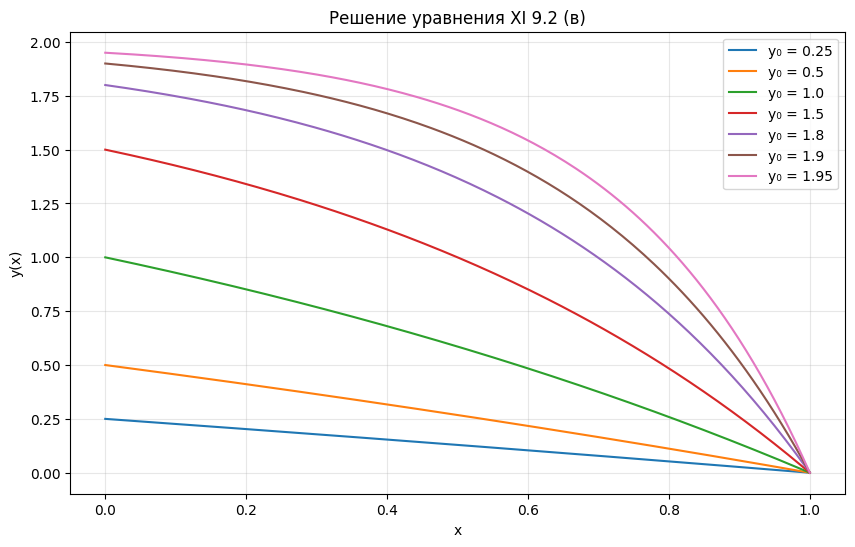

In [2]:
y0_values = [0.25, 0.5, 1.0, 1.5, 1.8, 1.9, 1.95]

def XI_92(x, y, yp):
    denominator = 1 - 0.5 * y
    return -0.5 / denominator * yp**2

plt.figure(figsize=(10, 6))

for y0 in y0_values:
    print(f"Решаем для y0 = {y0}")
    
    problem = SecondOrderEquation(
        f=XI_92,
        alpha=y0,   # y(0) = y0
        beta=0,     # y(1) = 0
        domain=(0, 1)
    )
    
    solver = QuasilinearizationSolver(problem, n_points=200)
    
    x, y = solver.solve(tol=1e-8, max_iter=50, verbose=False)
    
    plt.plot(x, y, label=f"y₀ = {y0}")

plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Решение уравнения XI 9.2 (в)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Решение той же задачи методом стрельбы

Решаем для y0 =  0.25
Решаем для y0 =  0.5
Решаем для y0 =  1.0
Решаем для y0 =  1.5
Решаем для y0 =  1.8
Решаем для y0 =  1.9
Решаем для y0 =  1.95


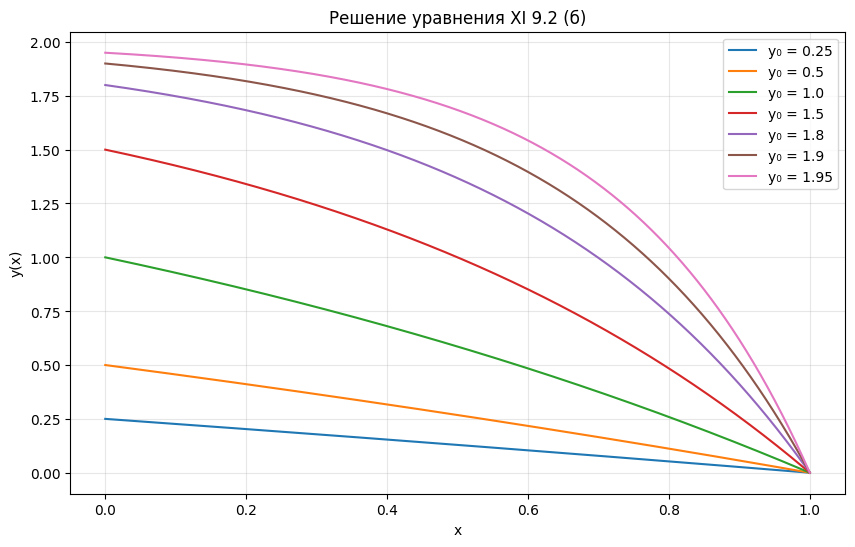

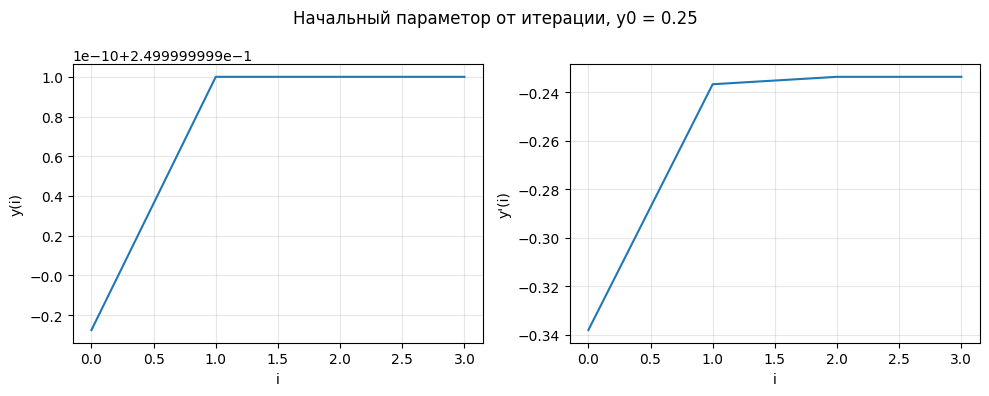

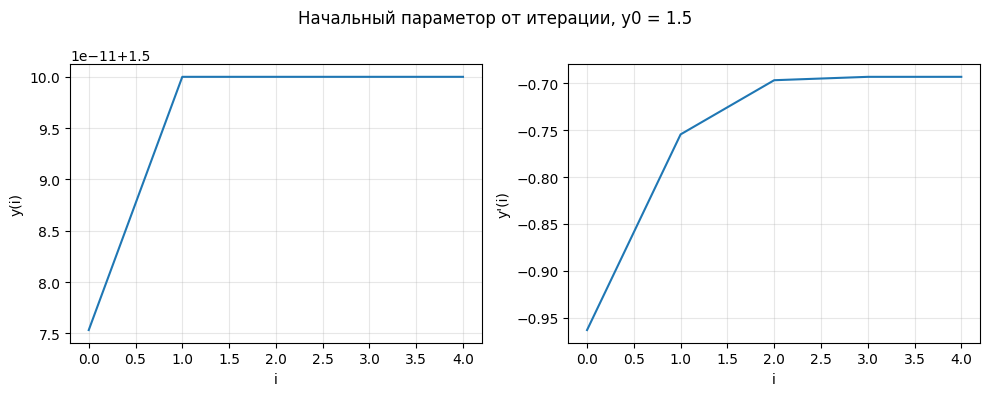

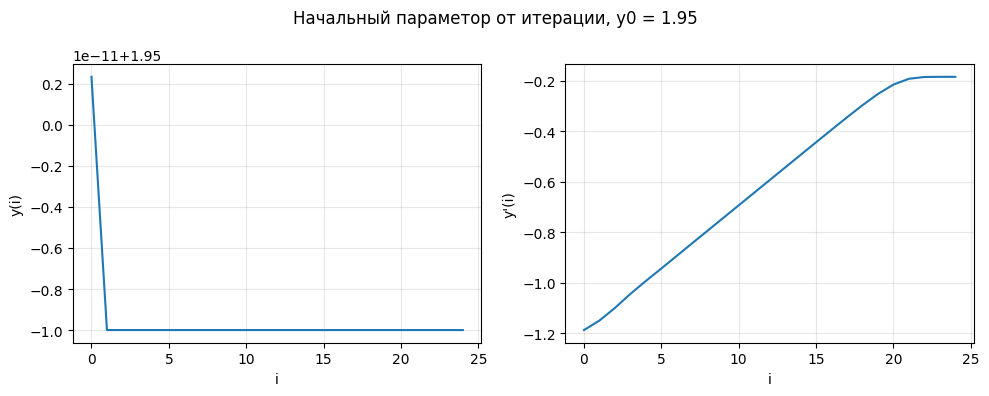

In [ ]:
# def system3(x, y):
#     return np.array([y[1], -y[0]])

def system_XI_92(x, y):

    return np.array([y[1], -0.5 / (1.0 - 0.5 * y[0]) * (y[1] ** 2)])

# одно начальное приближение для всех y0
a0 = [1.8, -0.1]

plt.figure(figsize=(10, 6))

# для графиков alpha(iter)
iters = []
alphas = []
yalphas = []

for y0 in y0_values:
    print("Решаем для y0 = ", y0)
    # def bc3(ya, yb):
        # y'(0) + 2y(0) = 3
        # y(1) = y0
        # return np.array([ya[1] + 2*ya[0] - 3, yb[0] - y0])
    
    def bc_XI_92(ya, yb):
        return np.array([ya[0] - y0, yb[0]])

    # problem3 = FirstOrderSystem(system3, bc3, domain=(0, np.pi / 2))
    problem3 = FirstOrderSystem(system_XI_92, bc_XI_92, domain=(0, 1))
    solver3 = ShootingSolver(problem3)
    x3, y3 = solver3.solve(a0, max_iter=50)

  
    iter, alpha = solver3.get_alphas()

    iters.append(iter)
    alphas.append(alpha)
    yalphas.append(y0)

    plt.plot(x3, list(map(lambda yn: yn[0], y3)), label=f"y₀ = {y0}")

plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Решение уравнения XI 9.2 (б)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

def make_alpha_graphs(i_list: list[float] = range(0, len(iters))):
    for i in i_list:
        fig, axes = plt.subplots(1, 2, figsize=[10, 4])
        fig.suptitle("Начальный параметор от итерации, y0 = " + str(yalphas[i]))

        plt.subplot(1, 2, 1)
        plt.plot(iters[i], list(map(lambda an: an[0], alphas[i])))
        plt.grid(True, alpha=0.3)
        axes[0].set_xlabel("i")
        axes[0].set_ylabel("y(i)")

        plt.subplot(1, 2, 2)
        plt.plot(iters[i], list(map(lambda an: an[1], alphas[i])))
        axes[1].set_xlabel("i")
        axes[1].set_ylabel("y'(i)")
        plt.grid(True, alpha=0.3)

        plt.tight_layout()

# не перегружаем вывод
make_alpha_graphs([0, 3, 6])
